https://github.com/ventolab/CellphoneDB/tree/master

NOTE: MUST USE HUMAN GENE NAMES, MAKE NEW OBJECT WITH THE SAME METHOD AS MOUSE GENE NAMES

In [110]:
import anndata  
import pandas as pd
import anndata as ad
import seaborn as sb
import scanpy as sc
import cellphonedb
import glob
import os
import sys

In [111]:
obj = anndata.io.read_h5ad('C:/Users/Gabe/Desktop/RNA_object_human_names_anndata.h5ad')
###IT WORKED

In [112]:
obj.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC',
       'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile',
       'peak_region_fragments', 'log10nfragments', 'pct_reads_in_peaks',
       'nucleosome_signal', 'nucleosome_percentile', 'individual', 'pct.mt',
       'pct.rb', 'pct.mt.rb', 'pct.cd', 'pct.nuclear', 'pct.ambient',
       'log10GenesPerUMI', 'log10PeaksPerUMI', 'genes_per_umi',
       'peaks_per_umi', 'pct_s.genes', 'pct_g2m.genes', 'percent_top50_genes',
       'percent_top100_genes', 'nuc_prep_batch', 'Tank', 'Trigger',
       'Prev_tank', 'Condition', 'Status', 'Status_Long', 'Time_Day_2',
       'Behaviors_Day_2', 'Change_Length', 'Change_Mass', 'Log_11KT',
       'Average_Area_2.5x', 'Total_Slides_With_Gonad', 'Estimated_Volume_2.5x',
       'Log10_Volume', 'Percent_Testicular', 'Testicular_Estimate',
       'Log10_Testicular_Estimate', 'pct.bad_nuc', 'pct.good_nuc', 'S.Score',
       'G2M.Score', 'Phase', 'median_UMI_count', 'median_gene_count',
     

https://github.com/ventolab/CellphoneDB/blob/master/notebooks/T0_DownloadDB.ipynb

Download cellphone db

In [113]:
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

I will make a folder where these are to be downloaded
A:\CellPhoneDB 030225

In [114]:
import os
import ssl
import urllib.request

# Create directory if it doesn't exist
cpdb_version = 'v5.0.0'
cpdb_target_dir = os.path.join('A:/CellPhoneDB 030225', cpdb_version)
os.makedirs(cpdb_target_dir, exist_ok=True)

# Create a custom opener with the unverified context
ssl_context = ssl._create_unverified_context()
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
urllib.request.install_opener(opener)

# Import and download database
from cellphonedb.utils import db_utils
db_utils.download_database(cpdb_target_dir, cpdb_version)

Downloaded cellphonedb.zip into A:/CellPhoneDB 030225\v5.0.0
Downloaded complex_input.csv into A:/CellPhoneDB 030225\v5.0.0
Downloaded gene_input.csv into A:/CellPhoneDB 030225\v5.0.0
Downloaded interaction_input.csv into A:/CellPhoneDB 030225\v5.0.0
Downloaded protein_input.csv into A:/CellPhoneDB 030225\v5.0.0
Downloaded uniprot_synonyms.tsv into A:/CellPhoneDB 030225\v5.0.0\sources
Downloaded transcription_factor_input.csv into A:/CellPhoneDB 030225\v5.0.0\sources


In [115]:
cpdb_target_dir

'A:/CellPhoneDB 030225\\v5.0.0'

https://github.com/ventolab/CellphoneDB/blob/master/notebooks/T1_Method1.ipynb

I have no idea why cellphone db is making me do all this stupid file path shit, why cant I just load in an object and tell it what the objects are

meta_file_path: (mandatory) path to the meta file linking cell barcodes to cluster labels metadata.tsv.

So I'm asuming this is a tsv file with the harmony wsnn cluster labels and teh cell barcodes, I can make this now 

In [133]:
cells = {
    "cell" : obj.obs.index,
    "harmony.wnn_res0.4_clusters" : obj.obs['harmony.wnn_res0.4_clusters']
    
}

cells = pd.DataFrame(cells)
cells

filename = "A:/CellPhoneDB 030225/cluster labels metadata.tsv"

cells.to_csv(filename, sep="\t") 


I think I did it

counts_file_path: (mandatory) paths to normalized counts file (not z-transformed), either in text format or h5ad (recommended) normalised_log_counts.h5ad.

Ok so this can be the data matrix which is lognormalized 

Ok X is data matrix

In [134]:
print(obj.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52581455 stored elements and shape (52517, 11115)>
  Coords	Values
  (0, 0)	4.257490310057351
  (0, 1)	6.308109535775182
  (0, 2)	2.8017765706326516
  (0, 3)	3.5784016335293867
  (0, 4)	4.077996309859363
  (0, 5)	3.1868001248195945
  (0, 6)	1.5827801206268868
  (0, 7)	2.167560461146175
  (0, 8)	1.5827801206268868
  (0, 9)	2.8017765706326516
  (0, 10)	3.1868001248195945
  (0, 11)	4.595485520638486
  (0, 12)	2.167560461146175
  (0, 13)	2.534126551823951
  (0, 14)	3.1868001248195945
  (0, 16)	2.167560461146175
  (0, 17)	2.167560461146175
  (0, 18)	3.464102558012661
  (0, 19)	2.534126551823951
  (0, 20)	2.8017765706326516
  (0, 21)	1.5827801206268868
  (0, 23)	1.5827801206268868
  (0, 24)	1.5827801206268868
  (0, 25)	1.5827801206268868
  (0, 26)	2.8017765706326516
  :	:
  (52516, 7128)	2.420937766945525
  (52516, 7167)	2.420937766945525
  (52516, 7237)	2.420937766945525
  (52516, 7372)	2.420937766945525
  (52516, 7439)	2.4209377

In [135]:
from scipy.sparse import csr_matrix
#counts_file_path: (mandatory) paths to normalized counts file (not z-transformed), either in text format or h5ad (recommended) normalised_log_counts.h5ad.
obj.X = csr_matrix(obj.X)
obj.X

#import hdf5plugin
#obj.write_h5ad('A:/CellPhoneDB 030225/normalised_log_counts')

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52581455 stored elements and shape (52517, 11115)>

Assign paths to objects

In [136]:
cpdb_file_path = 'A:/CellPhoneDB 030225/v5.0.0/cellphonedb.zip'
meta_file_path = 'A:/CellPhoneDB 030225/human_named_meta.tsv'
counts_file_path  = 'A:/CellPhoneDB 030225/normalised_log_counts.h5ad'
out_path = 'A:/CellPhoneDB 030225/'
degs_file_path = 'A:/CellPhoneDB 030225/human_named_DEGs.tsv'
degs =pd.read_csv(degs_file_path, sep = '\t')
degs['cluster'].value_counts()

cluster
27    1915
0     1354
8     1281
11    1220
1     1134
17    1113
13     928
2      882
4      878
3      843
24     832
9      827
23     777
5      757
6      753
18     714
25     709
19     698
20     684
31     681
14     582
15     555
29     534
21     508
22     481
7      418
12     399
28     378
30     333
16     308
10     296
26     284
Name: count, dtype: int64

Inspect input files

In [137]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata ## do I need to remove the first column?

,Cell,harmony.wnn_res0.4_clusters
0,T17D_AAACAGCCAAGGCCAA-1,7
1,D4M_AAACAGCCACCAGCAT-1,2
2,T19D_AAACAGCCACGTAATT-1,0
3,D4M_AAACATGCAACTAACT-1,1
4,T17D_AAACATGCAAGCTTAT-1,5
...,...,...
52512,T11D_TTTGTTGGTAAATTGC-1,15
52513,T11D_TTTGTTGGTAATTAGC-1,4
52514,T11D_TTTGTTGGTCCTTAGT-1,0
52515,T11D_TTTGTTGGTGACATAT-1,2


In [138]:
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(52517, 11115)

In [139]:
list(adata.obs.index).sort() == list(metadata['Cell']).sort()


True

Run basic analysis

030325 - I think this will work once I change the gene names to human

In [140]:
obj.var

,features
CELF2,CELF2
PCDHAC2,PCDHAC2
NRG3,NRG3
SYT1,SYT1
NRXN2,NRXN2
...,...
HOXC9,HOXC9
IL20RA,IL20RA
CSH2,CSH2
BMP15,BMP15


In [170]:
from cellphonedb.src.core.methods import cpdb_degs_analysis_method

cpdb_results = cpdb_degs_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                            # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                            # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,                        # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    degs_file_path = degs_file_path,                            # mandatory: tsv file with DEG to account.
    counts_data = 'gene_name',                                # defines the gene annotation in counts matrix.
    score_interactions = True,                                  # optional: whether to score interactions or not. 
    threshold = 0.1,                                            # defines the min % of cells expressing a gene for this to be employed in the analysis.
    result_precision = 3,                                       # Sets the rounding for the mean values in significan_means.
    separator = '|',                                            # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                              # Saves all intermediate tables emplyed during the analysis in pkl format.
    output_path = out_path,                                     # Path to save results
    output_suffix = None,                                       # Replaces the timestamp in the output files by a user defined string in the  (default: None)
    threads = 25
    )

[ ][CORE][04/03/25-00:13:57][INFO] [Cluster DEGs Analysis] Threshold:0.1 Precision:3
Reading user files...
The following user files were loaded successfully:
A:/CellPhoneDB 030225/normalised_log_counts.h5ad
A:/CellPhoneDB 030225/human_named_meta.tsv
A:/CellPhoneDB 030225/human_named_DEGs.tsv
[ ][CORE][04/03/25-00:14:03][INFO] Running Real Analysis
[ ][CORE][04/03/25-00:14:04][INFO] Running DEGs-based Analysis
[ ][CORE][04/03/25-00:14:04][INFO] Building results
[ ][CORE][04/03/25-00:14:04][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 32/32 [00:00<00:00, 36.69it/s]

[ ][CORE][04/03/25-00:14:05][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 32/32 [00:00<00:00, 129.57it/s]
c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\cellphonedb\utils\scoring_utils.py:138: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




[ ][CORE][04/03/25-00:14:06][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 1024/1024 [01:33<00:00, 10.92it/s]


Saved deconvoluted to A:/CellPhoneDB 030225/degs_analysis_deconvoluted_03_04_2025_001542.txt
Saved deconvoluted_percents to A:/CellPhoneDB 030225/degs_analysis_deconvoluted_percents_03_04_2025_001542.txt
Saved means to A:/CellPhoneDB 030225/degs_analysis_means_03_04_2025_001542.txt
Saved relevant_interactions to A:/CellPhoneDB 030225/degs_analysis_relevant_interactions_03_04_2025_001542.txt
Saved significant_means to A:/CellPhoneDB 030225/degs_analysis_significant_means_03_04_2025_001542.txt
Saved interaction_scores to A:/CellPhoneDB 030225/degs_analysis_interaction_scores_03_04_2025_001542.txt


IT FUCKING WORKED THANK YOU JESUS

In [142]:
print(cpdb_results.keys())

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'relevant_interactions', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted'])


<b>Means fields</b>:

<b>means</b>: Mean values for all the interacting partners: mean value refers to the total mean of the individual partner average expression values in the corresponding interacting pairs of cell types. If one of the mean values is 0, then the total mean is set to 0.

In [143]:
cpdb_results['means'].head(2)


,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,9|29,9|3,9|30,9|31,9|4,9|5,9|6,9|7,9|8,9|9
47,CPI-SS0EE09A201,CDH2_CDH2,simple:P19022,simple:P19022,CDH2,CDH2,False,False,False,curated,...,1.643,1.115,1.693,2.063,1.125,1.660,1.416,1.357,1.650,1.694
49,CPI-SS0DA0F5556,CDH3_CDH3,simple:P22223,simple:P22223,CDH3,CDH3,False,False,False,curated,...,0.028,0.017,0.018,0.000,0.016,0.018,0.022,0.022,0.025,0.027


OK, so the output looks like:

<b>interaction_pair</b>:  Unique CellphoneDB identifier for each interaction stored in the database.

<b>interacting_pair</b>: Name of the interacting pairs separated by “|”.

<b>partner A or B</b>: Identifier for the first interacting partner (A) or the second (B). It could be: UniProt (prefix simple:) or complex (prefix complex:)

<b>gene A or B</b>: Gene identifier for the first interacting partner (A) or the second (B). The identifier will depend on the input user list.

<b>secreted</b>: True if one of the partners is secreted.

<b>Receptor A or B</b>: True if the first interacting partner (A) or the second (B) is annotated as a receptor in our database.

<b>annotation_strategy</b>: Curated if the interaction was annotated by the CellphoneDB developers. Otherwise, the name of the database where the 
interaction has been downloaded from.

<b>is_integrin</b>: True if one of the partners is integrin.

<b>directionality</b>: Indiicates the directionality of the interaction and the charactersitics of the interactors.

<b>classification</b>: Pathway classification for the interacting partners.

So is there no p value here?

<b>Interaction scores fields</b>:

<b>scores</b>: Interaction scores ranging between 0 and 100. The higher the score is, the more specific the interaction is expected.

In [144]:
cpdb_results['relevant_interactions'].head(2)


,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,9|29,9|3,9|30,9|31,9|4,9|5,9|6,9|7,9|8,9|9
47,CPI-SS0EE09A201,CDH2_CDH2,simple:P19022,simple:P19022,CDH2,CDH2,False,False,False,curated,...,1,1,1,1,1,1,1,1,1,1
49,CPI-SS0DA0F5556,CDH3_CDH3,simple:P22223,simple:P22223,CDH3,CDH3,False,False,False,curated,...,0,0,0,0,0,0,0,0,0,0


<b>Deconvoluted fields:</b>

In [145]:
cpdb_results['deconvoluted'].head(2)


,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,0,1,10,...,29,3,30,31,4,5,6,7,8,9
multidata_id,,,,,,,,,,,,,,,,,,,,,
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS05760BB78,UBASH3B,0.216,0.142,0.42,...,0.115,0.075,0.056,0.096,0.447,0.076,0.11,0.24,0.2,0.28
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS0259A0EB4,UBASH3B,0.216,0.142,0.42,...,0.115,0.075,0.056,0.096,0.447,0.076,0.11,0.24,0.2,0.28


<b>Deconvoluted percents fields</b>:

<b>percents</b>: Percent of cells (clusters) expressing the given gene.

In [146]:
cpdb_results['deconvoluted_percents'].head(2)


,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,0,1,10,...,29,3,30,31,4,5,6,7,8,9
multidata_id,,,,,,,,,,,,,,,,,,,,,
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS05760BB78,UBASH3B,0.174,0.107,0.205,...,0.068,0.034,0.044,0.064,0.187,0.05,0.072,0.121,0.154,0.167
1355,UBASH3B,Q8TF42,True,UBS3B_HUMAN,Dehydroepiandrosterone_bySTS,CPI-CS0259A0EB4,UBASH3B,0.174,0.107,0.205,...,0.068,0.034,0.044,0.064,0.187,0.05,0.072,0.121,0.154,0.167


How do I save the cpdb_results object?

I cant actually figure out a good way so for now I guess I will just rerun it each time?

It looks like to do anything interesting I need to make a DEGs file from seurat

I think now that I gave it DEGs, it should give me a p.value? I dont really understand how to see which communication is significant. 

In [147]:
list(cpdb_results.keys())

['deconvoluted',
 'deconvoluted_percents',
 'means',
 'relevant_interactions',
 'significant_means',
 'CellSign_active_interactions',
 'CellSign_active_interactions_deconvoluted']

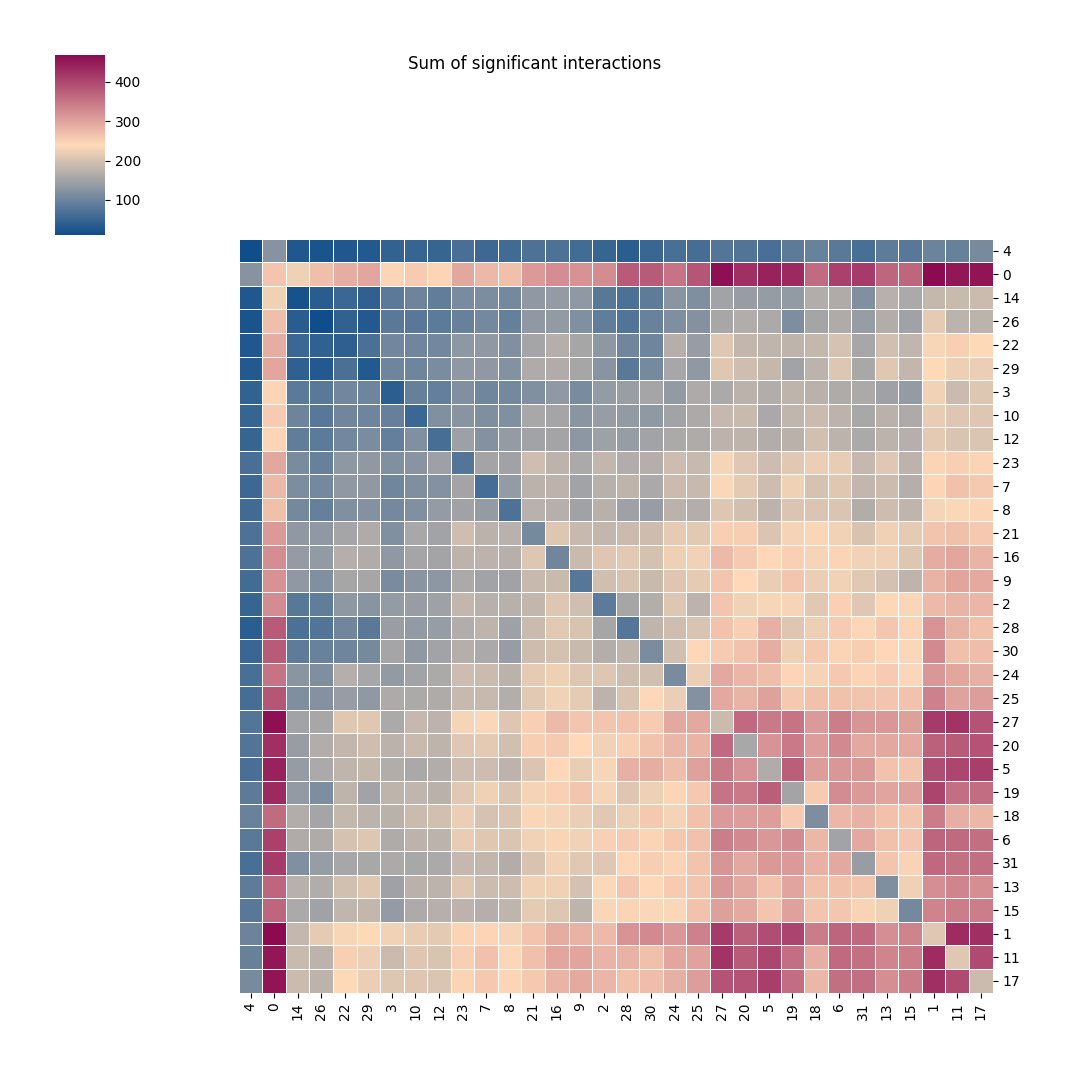

In [148]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

kpy.plot_cpdb_heatmap(pvals = cpdb_results['relevant_interactions'],
                      degs_analysis=True,
                      title="Sum of significant interactions")

I dont know why this doesnt work

In [149]:
adata.obs.columns
metadata.columns
cells.columns

Index(['cell', 'harmony.wnn_res0.4_clusters'], dtype='object')

In [ ]:
from plotnine import facet_wrap

adata.obs['harmony.wnn_res0.4_clusters'] = adata.obs['harmony.wnn_res0.4_clusters'].astype(str)
cells['harmony.wnn_res0.4_clusters'] =  cells['harmony.wnn_res0.4_clusters'].astype(str)
metadata['harmony.wnn_res0.4_clusters'] = metadata['harmony.wnn_res0.4_clusters'].astype(str)

p = kpy.plot_cpdb(
    adata = adata,
    cell_type1 = '27',
    cell_type2 = '0', 
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = "harmony.wnn_res0.4_clusters",
    genes = ["JAG1"],
    max_size = 6,
    highlight_size = 0.75,
    degs_analysis = False,
    standard_scale = False
)


c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\ktplotspy\plot\plot_cpdb.py:197: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


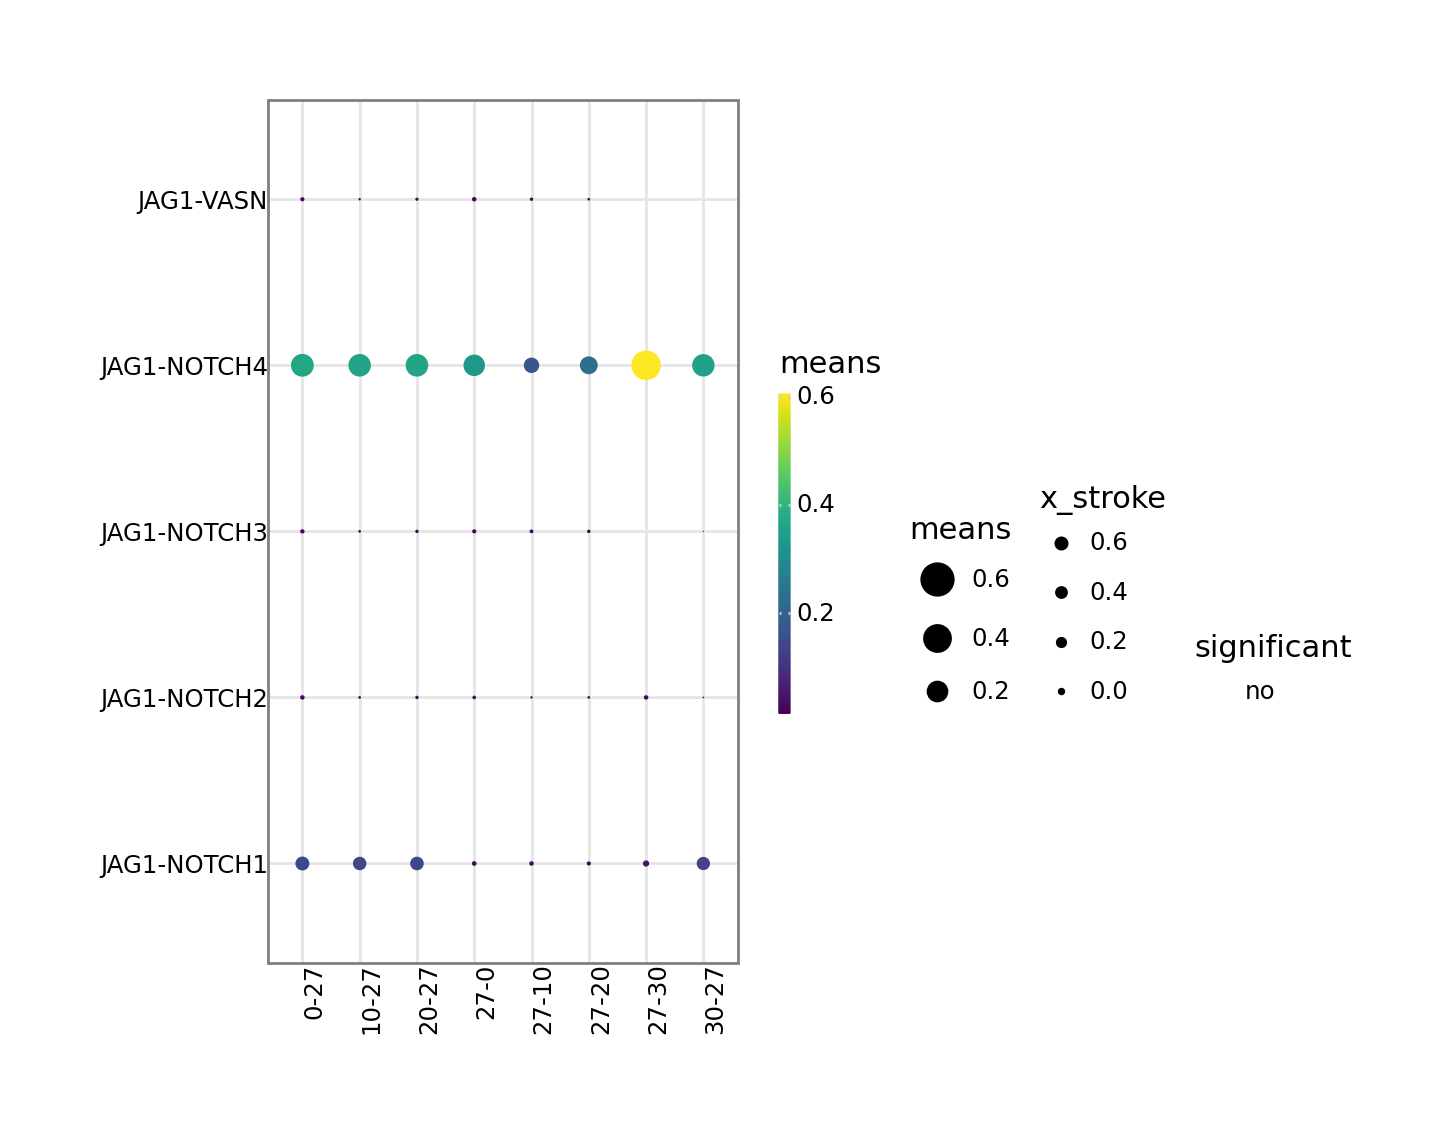

In [154]:
p

IT WORKED

c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\ktplotspy\plot\plot_cpdb.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


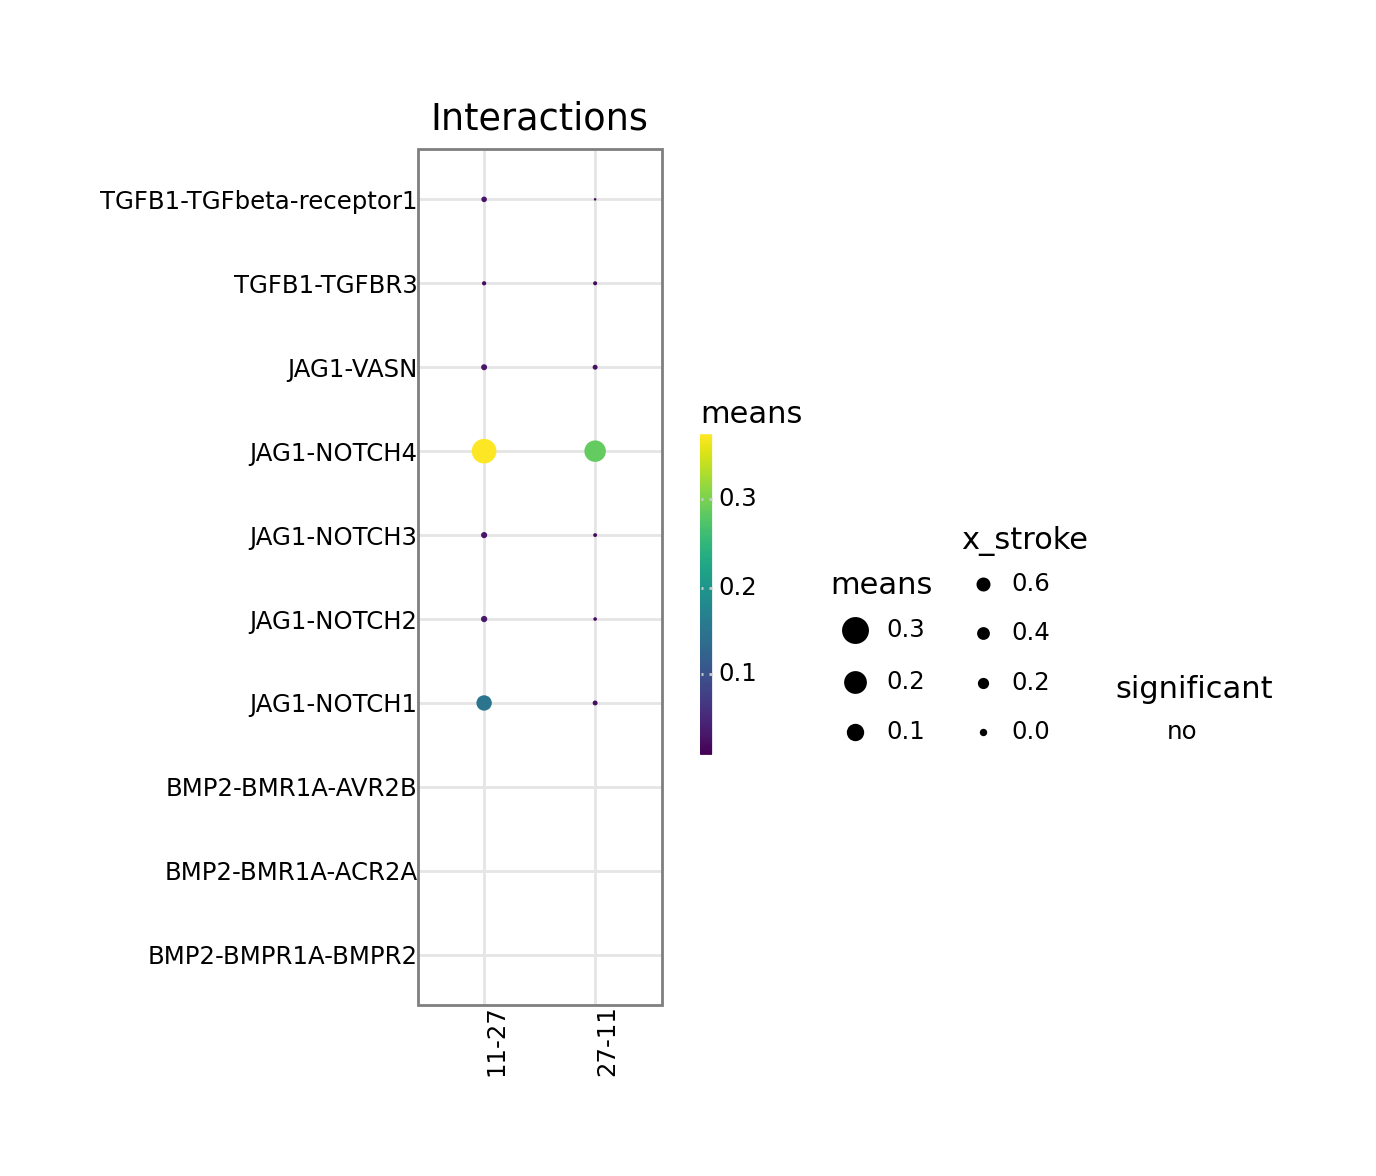

In [156]:


kpy.plot_cpdb(
    adata = adata,
    cell_type1 = '11',
    cell_type2 = '27', 
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = 'harmony.wnn_res0.4_clusters',
    genes = ["JAG1", "TGFB1", "BMP2"],
    figsize = (6,5),
    title = "Interactions",
    max_size = 5,
    highlight_size = 0.75,
    degs_analysis = True,
    standard_scale = False
)

Alright well these plots are not working, so how do I do this analysis unbiased anyway, how do I see the p values?

c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\ktplotspy\plot\plot_cpdb.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


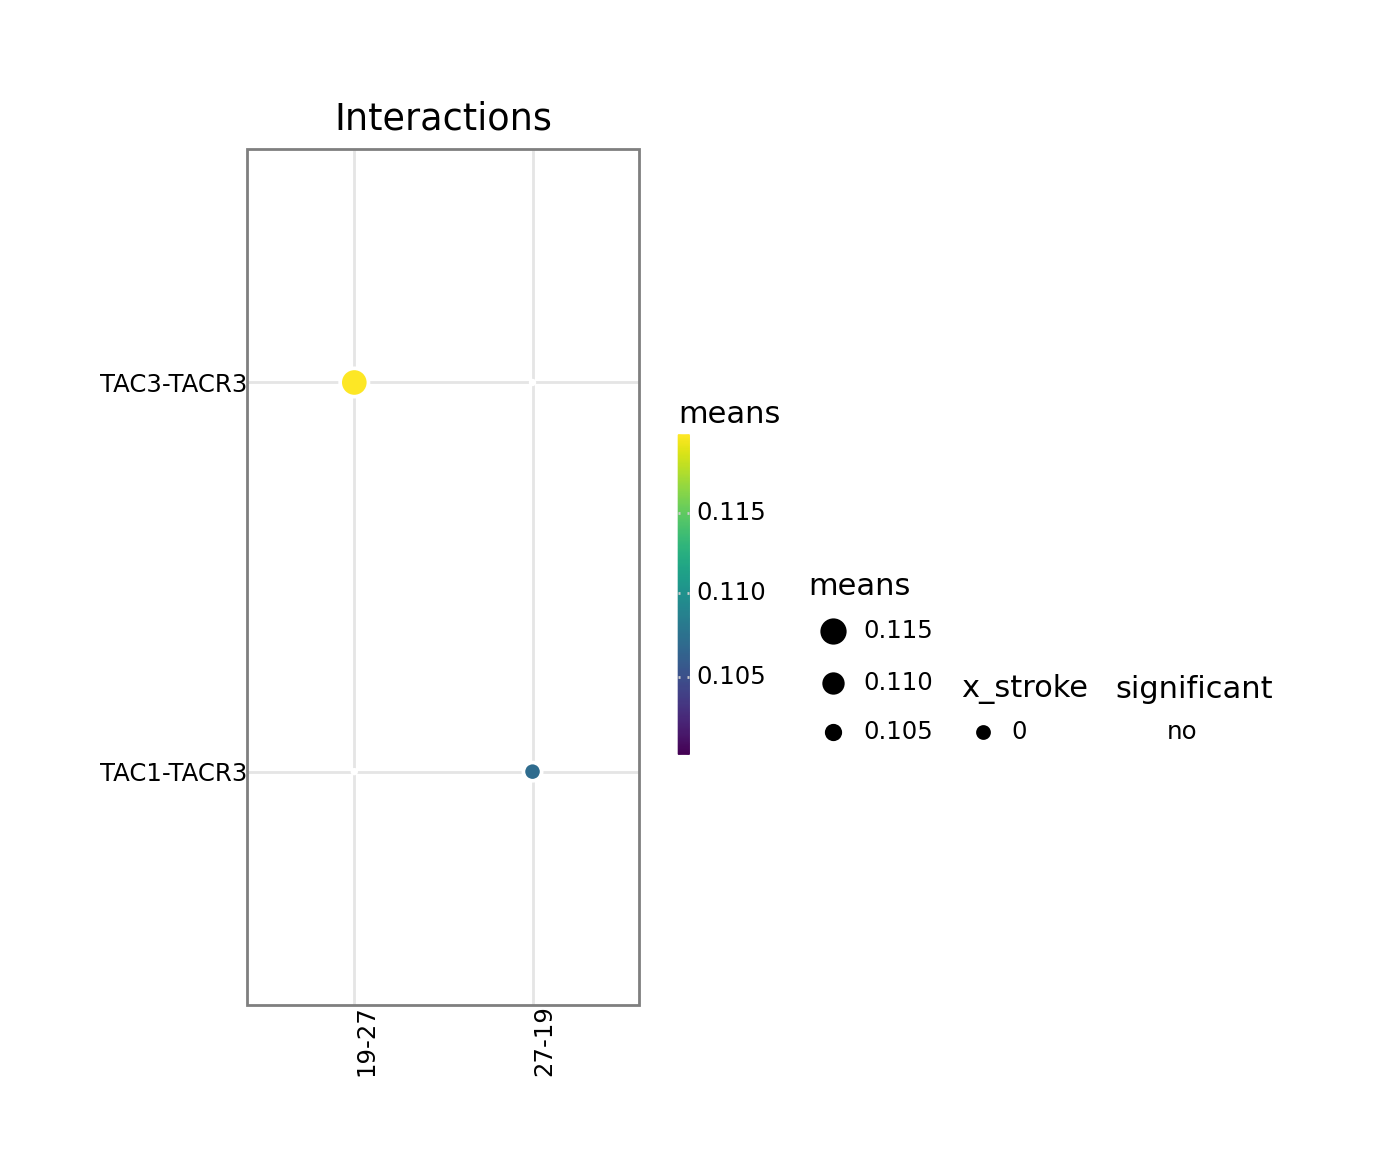

In [158]:

kpy.plot_cpdb(
    adata = adata,
    cell_type1 = '19',
    cell_type2 = '27', 
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = 'harmony.wnn_res0.4_clusters',
    genes = ["TACR3"],
    figsize = (6,5),
    title = "Interactions",
    max_size = 5,
    highlight_size = 0.75,
    degs_analysis = True,
    standard_scale = False
)

Rank overexpression and expression specificity

In [159]:
cpdb_results['significant_means'].head(3)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,9|29,9|3,9|30,9|31,9|4,9|5,9|6,9|7,9|8,9|9
2395,CPI-SS02704D1B8,WNT2_FRZB,simple:P09544,simple:Q92765,WNT2,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2397,CPI-SS0A10C2A8F,WNT3_FRZB,simple:P56703,simple:Q92765,WNT3,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2391,CPI-SS0961DD05D,WNT1_FRZB,simple:P04628,simple:Q92765,WNT1,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A REPLICATION - THE WNT PATHWAY 

In [160]:
cpdb_results['significant_means']

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,9|29,9|3,9|30,9|31,9|4,9|5,9|6,9|7,9|8,9|9
2395,CPI-SS02704D1B8,WNT2_FRZB,simple:P09544,simple:Q92765,WNT2,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2397,CPI-SS0A10C2A8F,WNT3_FRZB,simple:P56703,simple:Q92765,WNT3,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2391,CPI-SS0961DD05D,WNT1_FRZB,simple:P04628,simple:Q92765,WNT1,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2405,CPI-SS0D184698A,WNT8A_FRZB,simple:Q9H1J5,simple:Q92765,WNT8A,FRZB,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2239,CPI-CS008E4E6F9,SerotoninDopamin_byDDC_HTR5A,complex:SerotoninDopamin_byDDC,simple:P47898,NaN,HTR5A,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2904,CPI-SS0772C9606,REN_ATP6AP2,simple:P00797,simple:O75787,REN,ATP6AP2,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2905,CPI-SS016FD0C8A,RNASET2_TLR8,simple:O00584,simple:Q9NR97,RNASET2,TLR8,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2906,CPI-SS07D508428,SIGLEC15_CD44,simple:Q6ZMC9,simple:P16070,SIGLEC15,CD44,False,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,CPI-SS0BE3D537D,CDH7_CDH7,simple:Q9ULB5,simple:Q9ULB5,CDH7,CDH7,False,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
cols = ['id_cp_interaction', 'interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 'secreted', 'receptor_a', 'receptor_b', 'annotation_strategy', 'is_integrin', 'directionality', 'classification']
topmeans = pd.DataFrame({
    'max_exprmean_column': cpdb_results['significant_means'].drop(cols, axis=1).idxmax(axis=1),
    'max_exprmean_value': cpdb_results['significant_means'].drop(cols, axis=1).max(axis=1)
}).dropna().sort_values('max_exprmean_value', ascending=False)

In [162]:
topmeans

,max_exprmean_column,max_exprmean_value
662,11|7,5.224
667,17|7,4.689
668,13|7,4.519
650,11|12,4.298
661,11|7,4.181
...,...,...
1942,17|17,0.197
1240,27|4,0.193
2755,31|24,0.176
1941,5|17,0.174


Rank by scoring specificity

In [171]:
cols = ['id_cp_interaction', 'interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b', 
        'secreted', 'receptor_a', 'receptor_b', 'annotation_strategy', 'is_integrin', 'directionality', 'classification']

In [172]:
topscores = pd.DataFrame({
    'max_score_column': cpdb_results['interaction_scores'].drop(cols, axis=1).idxmax(axis=1),
    'max_score_value': cpdb_results['interaction_scores'].drop(cols, axis=1).max(axis=1)
}).dropna().sort_values('max_score_value', ascending=False)

In [ ]:
topscores.head(3)


,max_score_column,max_score_value
2909,30|19,100.0
47,31|31,100.0
49,14|14,100.0


Merge

In [180]:
merged_top_ranks = pd.merge(topmeans, topscores, left_index=True, right_index=True)
result = pd.concat([cpdb_results['significant_means'].loc[merged_top_ranks.index,cols], merged_top_ranks], axis=1)

In [182]:
result = result[result['max_exprmean_column'] == result['max_score_column'] ]

In [183]:
result = result.sort_values('max_exprmean_value', ascending=False)
result = result.sort_values('max_score_value', ascending=False)
result

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,is_integrin,directionality,classification,max_exprmean_column,max_exprmean_value,max_score_column,max_score_value
1662,CPI-SC0A86600AA,GDF10_ACVR_1B2B_receptor,simple:P55107,complex:ACVR_1B2B_receptor,GDF10,NaN,True,False,True,curated,False,Ligand-Receptor,Signaling by Growth differentiation factor,11|31,0.168,11|31,100.0
662,CPI-SS093707FE0,CLSTN2_NRXN2,simple:Q9H4D0,simple:P58401,CLSTN2,NRXN2,False,False,False,curated,False,Ligand-Receptor,Signaling by Calsyntenin,11|7,5.224,11|7,100.0
667,CPI-SS06157E5AF,LRRTM4_NRXN2,simple:Q86VH4,simple:P58401,LRRTM4,NRXN2,False,False,False,curated,False,Ligand-Receptor,Signaling by Leucine-Rich Repeat Transmembrane...,17|7,4.689,17|7,100.0
668,CPI-SS0CF0A8519,NLGN1_NRXN2,simple:Q8N2Q7,simple:P58401,NLGN1,NRXN2,False,False,False,curated,False,Ligand-Receptor,Signaling by Neuroligin,13|7,4.519,13|7,100.0
650,CPI-SS09A6C048C,CLSTN2_NRXN1,simple:Q9H4D0,simple:Q9ULB1,CLSTN2,NRXN1,False,False,False,curated,False,Ligand-Receptor,Signaling by Calsyntenin,11|12,4.298,11|12,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,CPI-SS0193D81E1,NRXN2_DAG1,simple:P58401,simple:Q14118,NRXN2,DAG1,True,False,True,curated,False,Receptor-Receptor,Signaling by Neurexin,7|9,3.509,7|9,100.0
1872,CPI-SS0E3C09735,NTN1_DSCAM,simple:O95631,simple:O60469,NTN1,DSCAM,True,False,False,curated,False,Ligand-Receptor,Signaling by Netrin,24|18,3.513,24|18,100.0
672,CPI-SS07C26C799,NLGN4Y_NRXN2,simple:Q8NFZ3,simple:P58401,NLGN4Y,NRXN2,False,False,False,curated,False,Ligand-Receptor,Signaling by Neuroligin,16|7,3.522,16|7,100.0
1634,CPI-CS054C4533B,Glutamate_byGLS_and_SLC17A6_GRM8,complex:Glutamate_byGLS_and_SLC17A6,simple:O00222,NaN,GRM8,True,False,True,curated,False,Ligand-Receptor,Signaling by Glutamate,27|16,3.529,27|16,100.0


In [184]:
topinteractions = result.interacting_pair[0:6]
topinteractions

1662    GDF10_ACVR_1B2B_receptor
662                 CLSTN2_NRXN2
667                 LRRTM4_NRXN2
668                  NLGN1_NRXN2
650                 CLSTN2_NRXN1
661                 CLSTN1_NRXN2
Name: interacting_pair, dtype: object

c:\Users\Gabe\AppData\Local\Programs\Python\Python312\Lib\site-packages\ktplotspy\plot\plot_cpdb.py:197: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


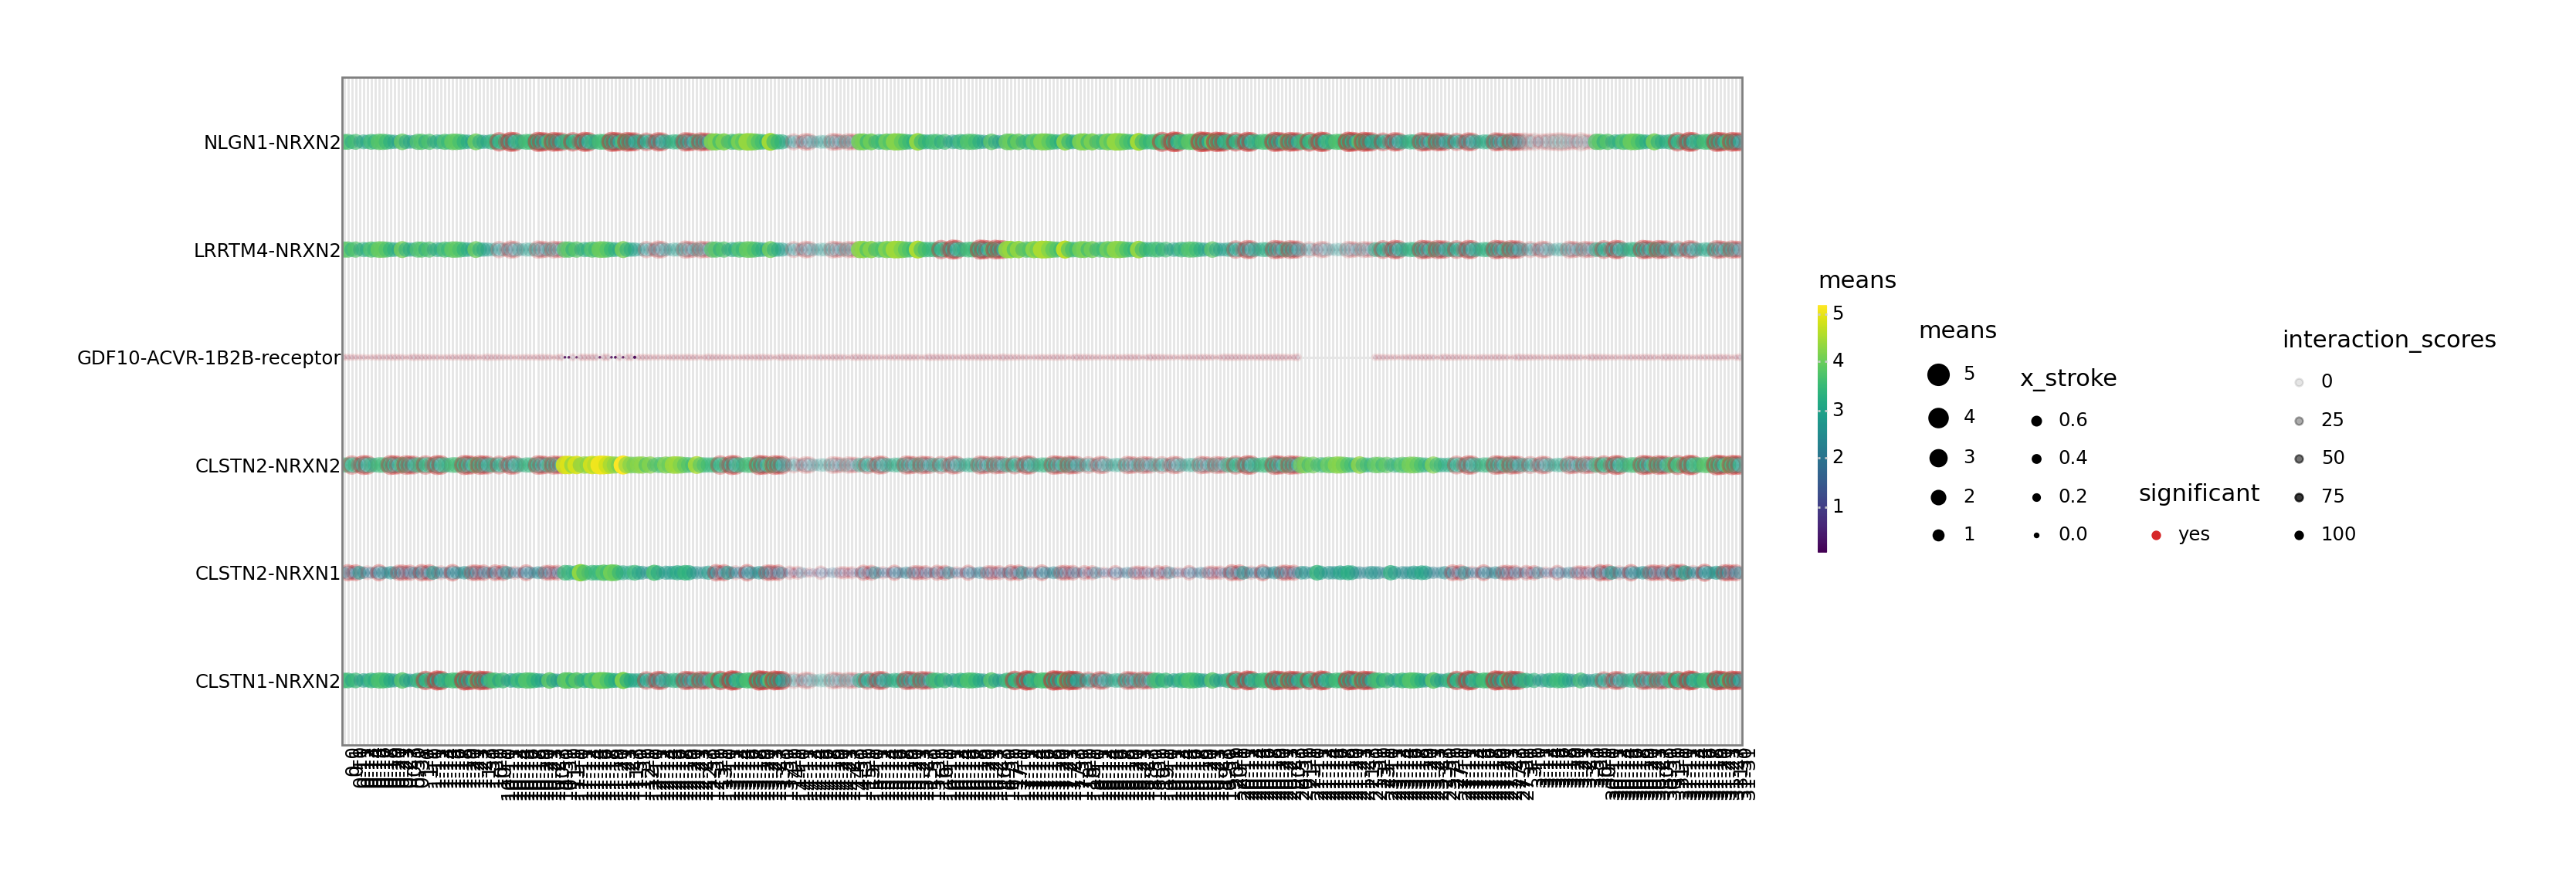

In [186]:
kpy.plot.plot_cpdb(
    adata = adata,
    cell_type1 = "0|1|3|27",
    cell_type2 = "0|1|3|27|20", 
    means = cpdb_results['means'],
    pvals = cpdb_results['relevant_interactions'],
    celltype_key = "harmony.wnn_res0.4_clusters",
    genes = topinteractions,
    figsize = (16,5),
    max_size = 5,
    highlight_size = 0.75,
    degs_analysis = False,
    standard_scale = False,
    interaction_scores = cpdb_results['interaction_scores'],
    scale_alpha_by_interaction_scores=True,
)

https://github.com/ventolab/CellphoneDB/blob/master/NatureProtocols2024_case_studies/CaseExample1_differentiation/visualisation_ktplots.ipynb

Requires bringing back into R